In [ ]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [63]:
df=pd.read_csv('loan_approval_dataset.csv')

In [64]:
df.head(3)

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes


In [65]:
df.isnull().sum()

Age                  0
Salary               0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Employment_Status    0
Residence_Type       0
Previous_Default     0
Loan_Approved        0
dtype: int64

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                1000 non-null   int64 
 1   Salary             1000 non-null   int64 
 2   Credit_Score       1000 non-null   int64 
 3   Loan_Amount        1000 non-null   int64 
 4   Loan_Term          1000 non-null   object
 5   Employment_Status  1000 non-null   object
 6   Residence_Type     1000 non-null   object
 7   Previous_Default   1000 non-null   object
 8   Loan_Approved      1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


In [67]:
df.columns=df.columns.str.strip()

In [68]:
df.duplicated().sum()

0

In [69]:
X=df.drop(columns='Loan_Approved')
y=df['Loan_Approved']

In [70]:
X.describe()

,Age,Salary,Credit_Score,Loan_Amount
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.986000,85197.154000,576.329000,27161.882000
std,13.497852,38105.636581,157.738607,12825.343062
min,18.000000,20060.000000,300.000000,5138.000000
25%,29.000000,52237.250000,442.000000,16181.750000
50%,42.000000,84850.500000,576.000000,26633.500000
75%,52.000000,117480.000000,709.750000,38002.000000
max,64.000000,149972.000000,849.000000,49900.000000


In [71]:
num_cols=X.select_dtypes(include='number').columns.tolist()
obj_cols=X.select_dtypes(include='object').columns.tolist()

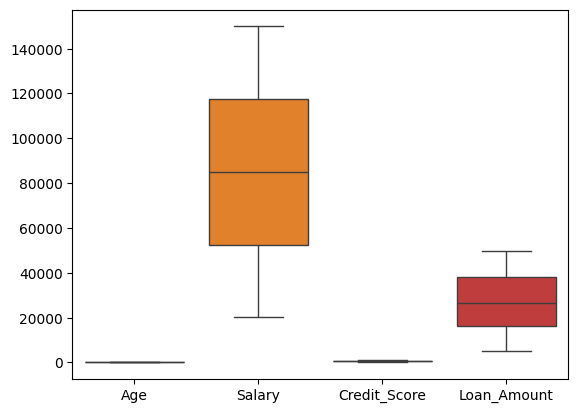

In [72]:
sns.boxplot(X[num_cols])
plt.show()

In [73]:
y.value_counts()

Loan_Approved
Yes    508
No     492
Name: count, dtype: int64

In [74]:
for col in obj_cols:
    print(col)
    print(X[col].unique()  ,'\n')

Loan_Term
['36 months' '24 months' '12 months' '48 months'] 

Employment_Status
['Employed' 'Self-Employed' 'Unemployed'] 

Residence_Type
['Owned' 'Rented' 'Mortgage'] 

Previous_Default
['Yes' 'No'] 



In [75]:
for col in obj_cols:
    df[col]=df[col].str.strip()

In [76]:
print(type(num_cols))

<class 'list'>


In [77]:
df.corr(numeric_only=True)

,Age,Salary,Credit_Score,Loan_Amount
Age,1.000000,0.060125,-0.018835,-0.000500
Salary,0.060125,1.000000,-0.011185,-0.000635
Credit_Score,-0.018835,-0.011185,1.000000,0.008741
Loan_Amount,-0.000500,-0.000635,0.008741,1.000000


In [78]:
Xtrain,Xtest,ytrain,ytest=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [79]:
preprocessing_lr=ColumnTransformer(
    transformers=[
        ('Scaling',StandardScaler(),num_cols),
        ('Encoding',OneHotEncoder(handle_unknown='ignore'),obj_cols),
        ]
)

In [80]:
main_pipeline=Pipeline(
    steps=[
        ('preprocess',preprocessing_lr),
        ('Model',LogisticRegression())
    ]
)

In [81]:
main_pipeline.fit(Xtrain,ytrain)

,steps,"[('preprocess', ...), ('Model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Scaling', ...), ('Encoding', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [82]:
pred_ytrain=main_pipeline.predict(Xtrain)
pred_ytest=main_pipeline.predict(Xtest)

In [83]:
print('confusion metrics: ')
print('Train: \n',confusion_matrix(ytrain,pred_ytrain))
print('Test: \n',confusion_matrix(ytest,pred_ytest))

confusion metrics: 
Train: 
 [[202 192]
 [168 238]]
Test: 
 [[51 47]
 [49 53]]


In [84]:
print('Accuracy Score: ')
print('Train:',accuracy_score(ytrain,pred_ytrain))
print('Test :',accuracy_score(ytest,pred_ytest))

Accuracy Score: 
Train: 0.55
Test : 0.52


In [85]:
print('Classification Report: ')
print(classification_report(ytrain,pred_ytrain))

Classification Report: 
              precision    recall  f1-score   support

          No       0.55      0.51      0.53       394
         Yes       0.55      0.59      0.57       406

    accuracy                           0.55       800
   macro avg       0.55      0.55      0.55       800
weighted avg       0.55      0.55      0.55       800



In [86]:
print(classification_report(ytest,pred_ytest))

              precision    recall  f1-score   support

          No       0.51      0.52      0.52        98
         Yes       0.53      0.52      0.52       102

    accuracy                           0.52       200
   macro avg       0.52      0.52      0.52       200
weighted avg       0.52      0.52      0.52       200



## Conclusion

The Logistic Regression model did not perform well on the Loan Approval dataset. The final model achieved an accuracy of **50%**, with precision, recall, and F1-score close to **0.50** for both the **Yes** and **No** classes. Additionally, hyperparameter tuning using GridSearchCV did not improve the model's performance.

These results indicate that the model is **underfitting** the dataset. Logistic Regression is a linear algorithm that assumes a linear relationship between the input features and the target variable. Since the loan approval problem likely contains complex and non-linear relationships among features such as applicant income, credit history, loan amount, education, and property area, the model is unable to learn meaningful decision boundaries.

As a result, Logistic Regression is not an appropriate model for this dataset. The next step is to experiment with **tree-based algorithms** such as Decision Tree, Random Forest, and Gradient Boosting, which can capture non-linear relationships and feature interactions more effectively. These models are expected to provide better predictive performance on the Loan Approval dataset.


In [87]:
tree_preprocessing=ColumnTransformer(
    transformers=[('Encoding',OneHotEncoder(handle_unknown='ignore'),obj_cols)]
)

In [88]:
main_pipeline=Pipeline(
    steps=[
        ('preprocess',tree_preprocessing),
        ('model',DecisionTreeClassifier(random_state=42))
    ]
)


In [89]:
grid_cv = GridSearchCV(
    estimator=main_pipeline,
    param_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [5, 10, 15, 20, 30, None],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__max_features': [None, 'sqrt', 'log2']
                },
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [90]:
grid_cv.fit(Xtrain,ytrain)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [5, 10, ...], 'model__max_features': [None, 'sqrt', ...], 'model__min_samples_leaf': [1, 2, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('Encoding', ...)]"


In [91]:
ytrain_pred=grid_cv.predict(Xtrain)
ytest_pred=grid_cv.predict(Xtest)

In [92]:
grid_cv.best_estimator_

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Encoding', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [93]:
grid_cv.best_params_

{'model__criterion': 'gini',
 'model__max_depth': 5,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 20}

In [94]:
grid_cv.best_score_

0.51

In [95]:
print('Classification Report: ')
print(classification_report(ytrain,ytrain_pred))

Classification Report: 
              precision    recall  f1-score   support

          No       0.59      0.45      0.51       394
         Yes       0.57      0.69      0.62       406

    accuracy                           0.57       800
   macro avg       0.58      0.57      0.57       800
weighted avg       0.58      0.57      0.57       800



In [96]:
print(classification_report(ytest,ytest_pred))

              precision    recall  f1-score   support

          No       0.50      0.40      0.44        98
         Yes       0.52      0.62      0.56       102

    accuracy                           0.51       200
   macro avg       0.51      0.51      0.50       200
weighted avg       0.51      0.51      0.50       200



## Conclusion

The Decision Tree classifier achieved a **training accuracy of 87%** but only **51% testing accuracy** on the Loan Approval dataset. The precision, recall, and F1-score on the training set were all above **0.85**, whereas these metrics dropped to approximately **0.50** on the test set.

This large gap between training and testing performance indicates that the Decision Tree has **overfitted** the training data. The model has learned the specific patterns and noise present in the training dataset rather than capturing general relationships that apply to unseen data.

Although GridSearchCV was used to tune the hyperparameters, the resulting model still exhibited poor generalization. This suggests that a single Decision Tree may not be the most suitable model for this dataset.

As the next step, ensemble learning algorithms such as **Random Forest** and **Gradient Boosting** should be evaluated. These methods combine multiple decision trees, helping to reduce overfitting and improve generalization, making them more robust for loan approval prediction.


In [98]:
main_pipeline=Pipeline(
    steps=[
        ('preprocess',tree_preprocessing),
        ('model',RandomForestClassifier(random_state=42))
    ]
)


In [99]:
grid_cv = GridSearchCV(
    estimator=main_pipeline,
    param_grid={
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [10, 20, 30, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2'],
        'model__bootstrap': [True, False]
    },
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [100]:
grid_cv.fit(Xtrain, ytrain)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__bootstrap': [True, False], 'model__max_depth': [10, 20, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('Encoding', ...)]"


In [101]:
print("Best Parameters:")
print(grid_cv.best_params_)

print("\nBest CV Score:")
print(grid_cv.best_score_)

Best Parameters:
{'model__bootstrap': False, 'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best CV Score:
0.5037499999999999


In [102]:
pred_ytrain_r=grid_cv.predict(Xtrain)
pred_ytest_r=grid_cv.predict(Xtest)

In [103]:
print("Train Confusion Matrix")
print(confusion_matrix(ytrain, pred_ytrain_r))

print("\nTest Confusion Matrix")
print(confusion_matrix(ytest, pred_ytest_r))

Train Confusion Matrix
[[261 133]
 [175 231]]

Test Confusion Matrix
[[55 43]
 [52 50]]


In [104]:
print('Classification Report: ')
print(classification_report(ytrain,pred_ytrain_r))
print(classification_report(ytest,pred_ytest_r))

Classification Report: 
              precision    recall  f1-score   support

          No       0.60      0.66      0.63       394
         Yes       0.63      0.57      0.60       406

    accuracy                           0.61       800
   macro avg       0.62      0.62      0.61       800
weighted avg       0.62      0.61      0.61       800

              precision    recall  f1-score   support

          No       0.51      0.56      0.54        98
         Yes       0.54      0.49      0.51       102

    accuracy                           0.53       200
   macro avg       0.53      0.53      0.52       200
weighted avg       0.53      0.53      0.52       200



In [105]:
best_model = grid_cv.best_estimator_

feature_names = best_model.named_steps['preprocess'].get_feature_names_out()

importance = best_model.named_steps['model'].feature_importances_

feature_importance = (
    pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    })
    .sort_values(by='Importance', ascending=False)
)

print(feature_importance.head(10))

                                     Feature  Importance
6     Encoding__Employment_Status_Unemployed    0.119772
8             Encoding__Residence_Type_Owned    0.106752
2              Encoding__Loan_Term_36 months    0.104967
4       Encoding__Employment_Status_Employed    0.098207
3              Encoding__Loan_Term_48 months    0.083038
7          Encoding__Residence_Type_Mortgage    0.082493
5  Encoding__Employment_Status_Self-Employed    0.080055
9            Encoding__Residence_Type_Rented    0.078618
0              Encoding__Loan_Term_12 months    0.074464
1              Encoding__Loan_Term_24 months    0.073738


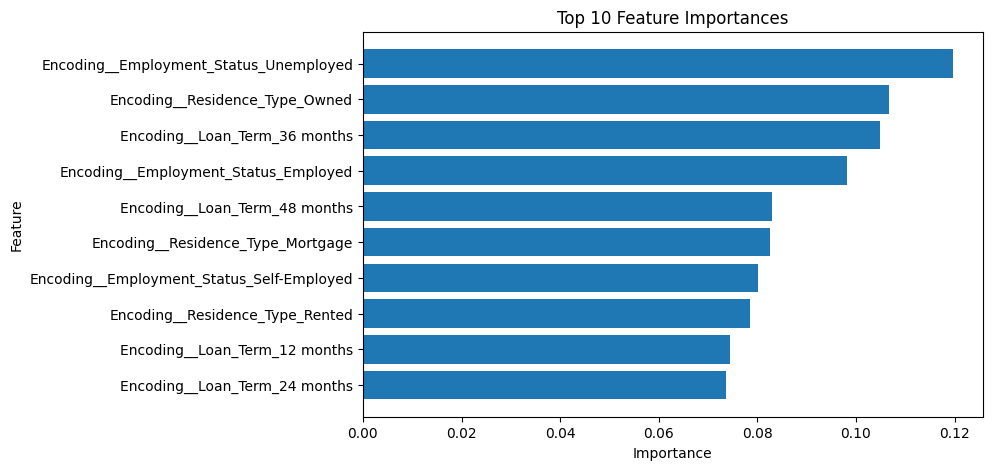

In [106]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [107]:
df.head()

df.sample(10)

df.groupby("Loan_Approved").mean(numeric_only=True)

pd.crosstab(df["Employment_Status"], df["Loan_Approved"])

pd.crosstab(df["Previous_Default"], df["Loan_Approved"])

pd.crosstab(df["Residence_Type"], df["Loan_Approved"])

Loan_Approved,No,Yes
Residence_Type,,
Mortgage,179,167
Owned,157,171
Rented,156,170


### Observations

1. `Logistic Regression`

- Training Accuracy: 55%
- Testing Accuracy: 52%

The training and testing accuracies are very close, indicating the model is not overfitting. However, both accuracies are low, suggesting underfitting. A linear model is unable to capture sufficient patterns in the data.

2. `Decision Tree`

- Training Accuracy: 57%
- Testing Accuracy: 51%

The gap between training and testing accuracy is only about 6%.

Earlier, the untuned tree reached around 87% training accuracy, showing clear overfitting. After hyperparameter tuning (max_depth=5, min_samples_split=20), the tree became much simpler, reducing overfitting but also reducing its ability to fit the training data. The result is a model that generalizes slightly better but still performs poorly overall.

3. `Random Forest`

- Training Accuracy: 61%
- Testing Accuracy: 53%

This is your best model so far.

The train–test gap is only 8%, much smaller than before, which means hyperparameter tuning successfully reduced overfitting.

Although the performance improvement is modest, the Random Forest is the strongest model among the three.

### Final Conclusions

- Logistic Regression: 

    - Underfit the dataset because it achieved similar but low training and testing accuracies, indicating that a linear model could not capture the underlying relationships.

- Decision Tree: 

     - Hyperparameter tuning reduced the severe overfitting seen initially. The tuned model generalized better but still learned only weak patterns, resulting in modest performance.

- Random Forest: 

    - Achieved the highest test accuracy (53%) and the best balance between training and testing performance. While it outperformed the other models, the overall predictive performance remained limited, suggesting that the available 
     - features do not provide strong predictive information for the target.